In [2]:
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from rich.progress import Progress
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
lr = 0.0002
b1 = 0.5
b2 = 0.999
batch_size = 128
epochs = 50
latent_dim = 100
img_shape = (1, 28, 28)

In [4]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

mnist_data = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
dataloader = DataLoader(mnist_data, batch_size=batch_size, shuffle=True, drop_last=True)

In [5]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_classes: Optional[int] = None):
        super(Generator, self).__init__()
        self.num_classes = num_classes

        input_dim = latent_dim + (num_classes if num_classes else 0)

        if num_classes is not None:
            self.label_embedding = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh(),
        )

    def forward(self, noise, labels=None):
        if self.num_classes and labels is not None:
            c = self.label_embedding(labels)
            x = torch.cat([noise, c], dim=1)
        else:
            x = noise

        img = self.model(x)
        return img.view(img.size(0), *img_shape)


class Discriminator(nn.Module):
    def __init__(self, num_classes=None):
        super(Discriminator, self).__init__()
        self.num_classes = num_classes

        input_dim = int(np.prod(img_shape)) + (num_classes if num_classes else 0)

        if num_classes is not None:
            self.label_embedding = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, img, labels=None):
        img_flat = img.view(img.size(0), -1)

        if self.num_classes and labels is not None:
            c = self.label_embedding(labels)
            x = torch.cat([img_flat, c], dim=1)
        else:
            x = img_flat

        validity = self.model(x)
        return validity

In [6]:
def trainer(
    generator, discriminator, conditional=False, epochs=epochs, lr=lr, b1=b1, b2=b2
):
    criterion = nn.BCELoss()

    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

    static_noise = torch.randn(25, latent_dim, device=device)
    static_labels = torch.randint(0, 10, (25,), device=device) if conditional else None
    losses = []

    with Progress() as progress:
        epoch_task = progress.add_task("[cyan]Training[/cyan]", total=epochs)

        for epoch in range(epochs):
            batch_task = progress.add_task(
                f"[green]Epoch {epoch + 1}/{epochs}[/green]", total=len(dataloader)
            )

            for imgs, labels in dataloader:
                real_imgs = imgs.to(device)
                labels = labels.to(device) if conditional else None
                curr_bs = real_imgs.size(0)

                valid = torch.ones(curr_bs, 1, device=device)
                fake = torch.zeros(curr_bs, 1, device=device)

                optimizer_D.zero_grad()

                real_pred = discriminator(real_imgs, labels)
                d_real_loss = criterion(real_pred, valid)

                z = torch.randn(curr_bs, latent_dim, device=device)
                gen_labels = (
                    torch.randint(0, 10, (curr_bs,), device=device)
                    if conditional
                    else None
                )
                gen_imgs = generator(z, gen_labels)

                fake_pred = discriminator(gen_imgs.detach(), gen_labels)
                d_fake_loss = criterion(fake_pred, fake)

                d_loss = (d_real_loss + d_fake_loss) / 2
                d_loss.backward()
                optimizer_D.step()

                optimizer_G.zero_grad()

                g_pred = discriminator(gen_imgs, gen_labels)
                g_loss = criterion(g_pred, valid)

                g_loss.backward()
                optimizer_G.step()

                progress.update(batch_task, advance=1)

            progress.remove_task(batch_task)
            progress.update(epoch_task, advance=1)

            losses.append((d_loss.item(), g_loss.item()))

            if (epoch + 1) % 10 == 0:
                generator.eval()
                with torch.no_grad():
                    gen_imgs = generator(static_noise, static_labels).cpu()
                generator.train()

                _, axes = plt.subplots(5, 5, figsize=(5, 5))
                for idx, ax in enumerate(axes.flatten()):
                    ax.imshow(gen_imgs[idx][0], cmap="gray")
                    ax.axis("off")
                    if conditional and static_labels is not None:
                        ax.set_title(f"{static_labels[idx].item()}", fontsize=8)

                plt.suptitle(f"Epoch {epoch + 1}")
                plt.tight_layout()
                plt.show()

    return losses

Output()

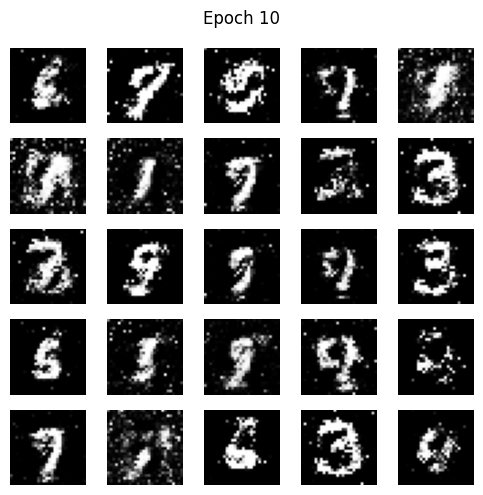

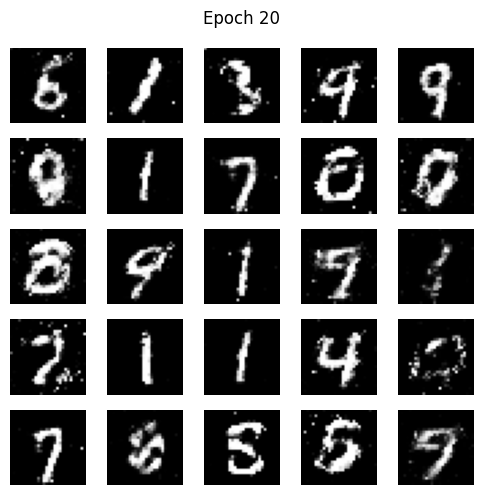

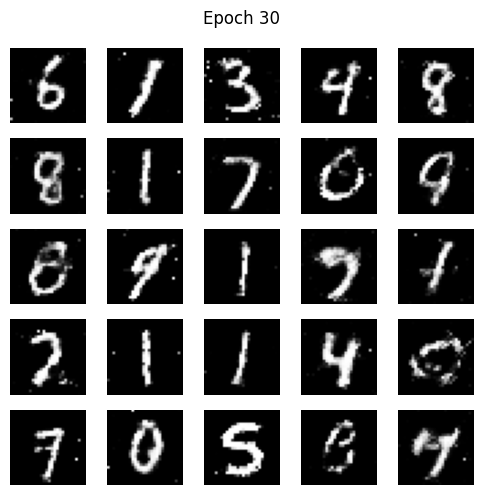

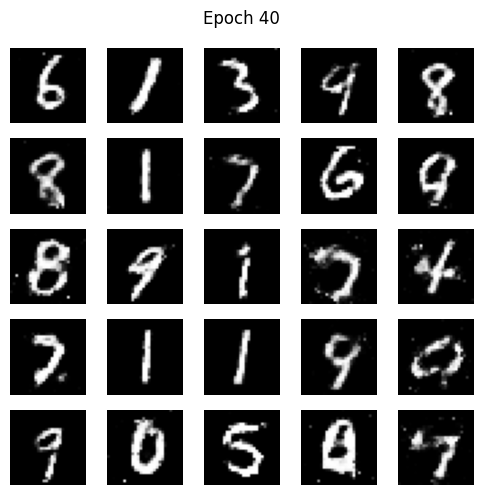

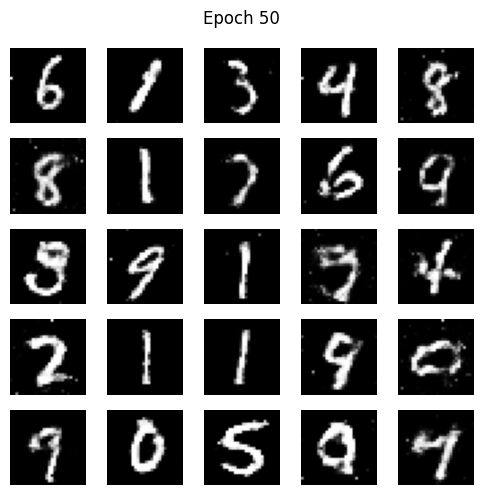

In [6]:
vanilla_G = Generator(latent_dim).to(device)
vanilla_D = Discriminator().to(device)

losses = trainer(vanilla_G, vanilla_D, conditional=False)

torch.save(losses, "part1_losses.pth")
torch.save(vanilla_G.state_dict(), "part1.pth")

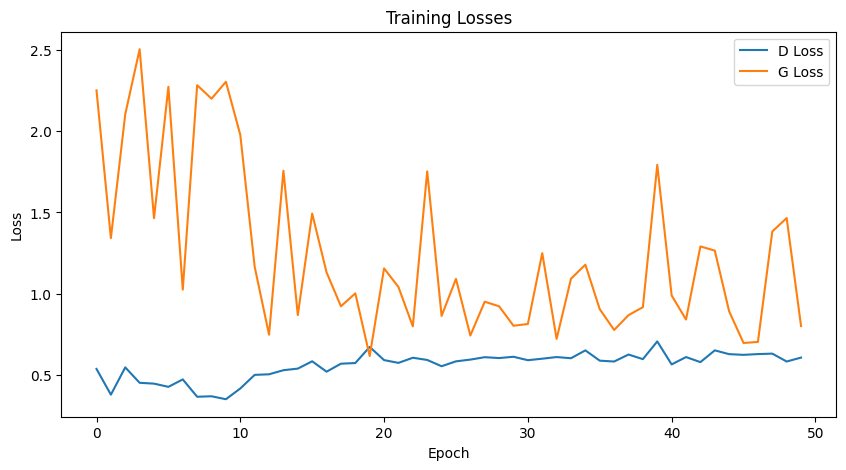

In [7]:
plt.figure(figsize=(10, 5))
plt.plot([l[0] for l in losses], label="D Loss")
plt.plot([l[1] for l in losses], label="G Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Losses")
plt.show()

Output()

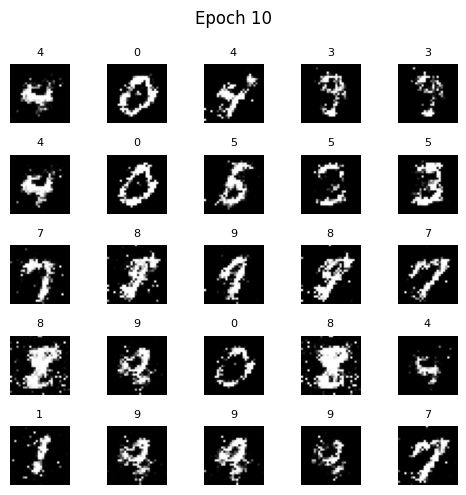

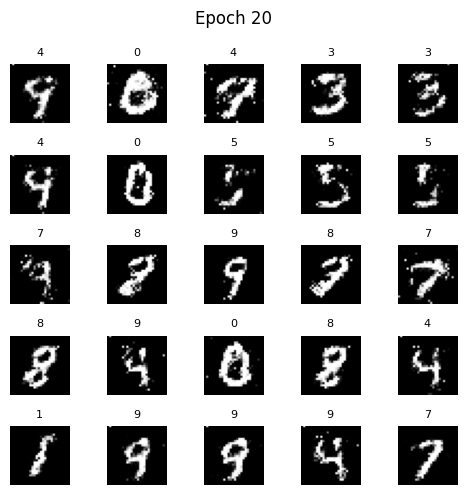

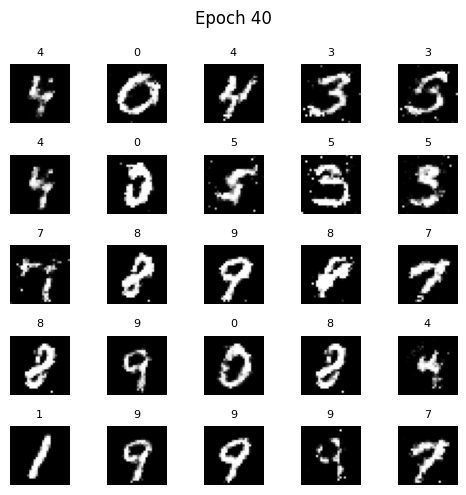

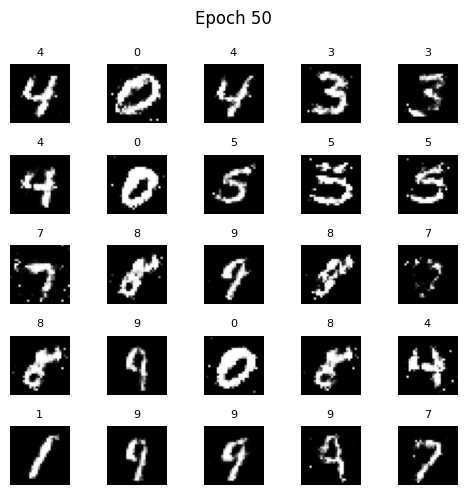

In [9]:
c_G = Generator(latent_dim, num_classes=10).to(device)
c_D = Discriminator(num_classes=10).to(device)

losses = trainer(c_G, c_D, conditional=True)

torch.save(losses, "part2_losses.pth")
torch.save(c_G.state_dict(), "part2.pth")

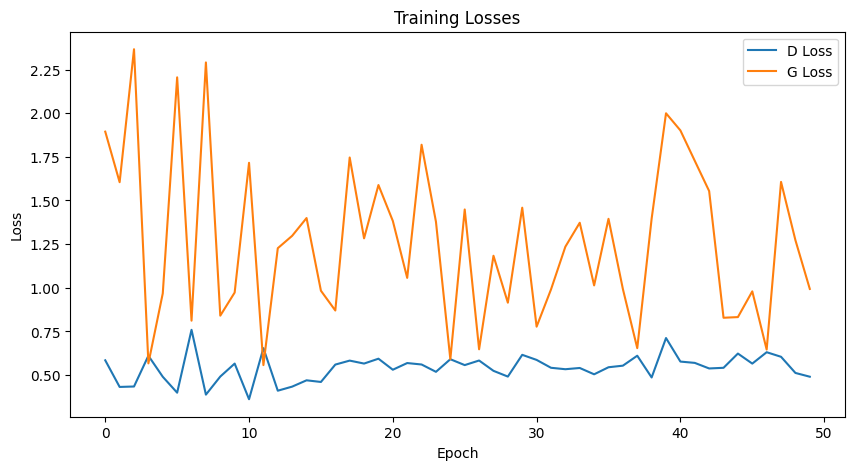

In [10]:
plt.figure(figsize=(10, 5))
plt.plot([l[0] for l in losses], label="D Loss")
plt.plot([l[1] for l in losses], label="G Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Losses")
plt.show()

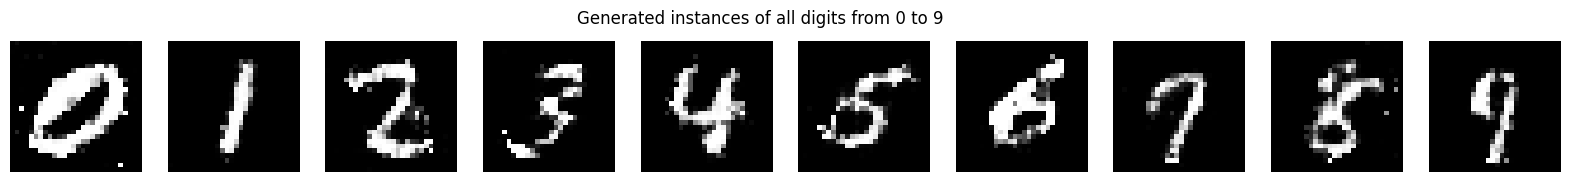

In [19]:
c_G.eval()

with torch.no_grad():
    z = torch.randn(10, latent_dim, device=device)
    labels = torch.arange(10, dtype=torch.long, device=device)

    gen_dig = c_G(z, labels).cpu()

fig, axes = plt.subplots(1, 10, figsize=(20, 2))
for i, ax in enumerate(axes):
    ax.imshow(gen_dig[i][0], cmap="gray")
    ax.axis("off")
plt.suptitle("Generated instances of all digits from 0 to 9")
plt.show()